# Resolve — Customer Service Resolution Time Prediction

Resolve is an end-to-end machine learning project that predicts how many days a Melbourne City customer service request may take to be resolved.

The project covers the complete machine learning workflow:

**Data Collection → Data Cleaning → Exploratory Data Analysis → Feature Engineering → Model Training → Evaluation → Prediction**

### Problem Type
Regression

### Target Variable
`days_to_complete`

### Dataset
Melbourne City Open Data

### Dataset Size
1,000 customer service requests

### Project Goal
To estimate the expected resolution time of a customer service request using information available when the request is received.

## 1. Project Definition

### Problem

Can we predict how many days a customer service request will take to be completed based on information available when the request is received?

### Target

`days_to_complete`

The target represents the number of days between receiving and completing a customer service request.

### Why is this useful?

Estimating resolution time can provide a rough expectation of how long different types of service requests may take to resolve and can help identify differences between service types.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

print("Resolve project started.")

Resolve project started.


## 2. Data Collection

The dataset was collected from the Melbourne City Open Data API.

Only requests with `CLOSED` status were selected because the project focuses on completed requests for which the actual resolution time is known.

The API was queried in batches of 100 records using pagination.

In [5]:
url = (
    "https://data.melbourne.vic.gov.au/api/explore/v2.1/"
    "catalog/datasets/customer-service-requests-with-resolution-time/"
    "records"
)

all_records = []

limit = 100
offset = 0
max_records = 1000

while len(all_records) < max_records:

    params = {
        "limit": limit,
        "offset": offset,
        "where": 'request_status="CLOSED"'
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    records = response.json()["results"]
    all_records.extend(records)

    print(f"Records collected: {len(all_records)}")

    if len(records) < limit:
        break

    offset += limit

df = pd.DataFrame(all_records[:max_records])

print("\nFinal dataset shape:", df.shape)

Records collected: 100
Records collected: 200
Records collected: 300
Records collected: 400
Records collected: 500
Records collected: 600
Records collected: 700
Records collected: 800
Records collected: 900
Records collected: 1000

Final dataset shape: (1000, 7)


## 3. Data Understanding

The first step is to inspect the structure, data types, missing values and basic statistics of the dataset.

In [6]:
df.head()

,request_status,date_received,date_completed,suburb,category,service_desc,days_to_complete
0,CLOSED,2015-11-19,2015-12-15,NaN,Roads and Traffic,Traffic Management,26
1,CLOSED,2015-09-14,2015-09-14,Melbourne,Parking,Parking Compliance Services,1
2,CLOSED,2015-04-27,2015-05-12,Carlton,Parks and Trees,Tree Maintenance Services,15
3,CLOSED,2015-03-12,2015-03-23,East Melbourne,Graffiti,Graffiti Removal,11
4,CLOSED,2016-04-07,2016-04-14,North Melbourne,Graffiti,Graffiti Removal,7


In [7]:
print("Shape:", df.shape)

Shape: (1000, 7)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   request_status    1000 non-null   str  
 1   date_received     1000 non-null   str  
 2   date_completed    1000 non-null   str  
 3   suburb            445 non-null    str  
 4   category          1000 non-null   str  
 5   service_desc      1000 non-null   str  
 6   days_to_complete  1000 non-null   int64
dtypes: int64(1), str(6)
memory usage: 124.9 KB


In [9]:
df.describe()

,days_to_complete
count,1000.0000
mean,14.2480
std,40.0317
min,1.0000
25%,2.0000
50%,5.0000
75%,12.0000
max,529.0000


In [10]:
df.isna().sum()

request_status        0
date_received         0
date_completed        0
suburb              555
category              0
service_desc          0
days_to_complete      0
dtype: int64

In [11]:
df["request_status"].value_counts()

request_status
CLOSED    1000
Name: count, dtype: int64

### Initial Findings

- The dataset contains 1,000 customer service requests.
- `days_to_complete` is the target variable.
- All selected records have `CLOSED` status.
- `suburb` contains a substantial number of missing values.
- `date_received` and `date_completed` are initially stored as object values.
- The target variable is right-skewed, with some requests taking considerably longer than the majority.

## 4. Data Dictionary

The main variables used in the dataset are described below.

In [12]:
data_dictionary = pd.DataFrame({
    "Variable": [
        "request_status",
        "date_received",
        "date_completed",
        "suburb",
        "category",
        "service_desc",
        "days_to_complete"
    ],
    "Type": [
        "Categorical",
        "Date",
        "Date",
        "Categorical",
        "Categorical",
        "Categorical",
        "Numeric"
    ],
    "Description": [
        "Current status of the request",
        "Date when the request was received",
        "Date when the request was completed",
        "Suburb where the request was reported",
        "Main service category",
        "Detailed service type",
        "Number of days required to complete the request"
    ]
})

data_dictionary

,Variable,Type,Description
0,request_status,Categorical,Current status of the request
1,date_received,Date,Date when the request was received
2,date_completed,Date,Date when the request was completed
3,suburb,Categorical,Suburb where the request was reported
4,category,Categorical,Main service category
5,service_desc,Categorical,Detailed service type
6,days_to_complete,Numeric,Number of days required to complete the request


## 5. Data Cleaning

Before modeling, date fields are converted to datetime format and missing values are investigated.

The `suburb` column contains many missing values. These records will not be removed because doing so would unnecessarily reduce the dataset. Instead, missing suburb values will later be represented as `Unknown` during preprocessing.

`request_status` will not be used as a model feature because all selected records have the same value: `CLOSED`.

In [13]:
df["date_received"] = pd.to_datetime(df["date_received"])
df["date_completed"] = pd.to_datetime(df["date_completed"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   request_status    1000 non-null   str           
 1   date_received     1000 non-null   datetime64[us]
 2   date_completed    1000 non-null   datetime64[us]
 3   suburb            445 non-null    str           
 4   category          1000 non-null   str           
 5   service_desc      1000 non-null   str           
 6   days_to_complete  1000 non-null   int64         
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 105.4 KB


In [14]:
print("Missing values after date conversion:")
display(df.isna().sum())

Missing values after date conversion:


request_status        0
date_received         0
date_completed        0
suburb              555
category              0
service_desc          0
days_to_complete      0
dtype: int64

## 6. Exploratory Data Analysis

### Resolution Time Distribution

First, we examine the distribution of the target variable.

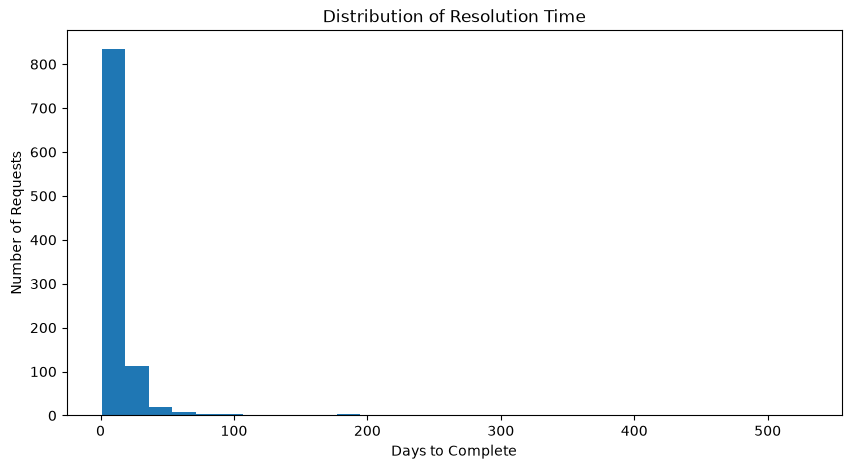

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(df["days_to_complete"], bins=30)

plt.xlabel("Days to Complete")
plt.ylabel("Number of Requests")
plt.title("Distribution of Resolution Time")

plt.show()

### Interpretation

The target variable is strongly right-skewed. Most requests are completed relatively quickly, while a smaller number take much longer.

This distribution is important because extreme resolution times can strongly affect regression models. Therefore, a log-transformed target will also be tested later.

In [16]:
df["days_to_complete"].describe()

count    1000.0000
mean       14.2480
std        40.0317
min         1.0000
25%         2.0000
50%         5.0000
75%        12.0000
max       529.0000
Name: days_to_complete, dtype: float64

In [17]:
df["days_to_complete"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

0.50      5.00
0.75     12.00
0.90     26.00
0.95     39.00
0.99    232.16
Name: days_to_complete, dtype: float64

### Target Variable Findings

The difference between the mean and median resolution time indicates that long-duration requests have a noticeable effect on the average.

These values were not automatically removed as outliers. They represent real observations and will first be considered during modeling and error analysis.

### Resolution Time by Category

Resolution time may differ between service categories.

In [18]:
category_summary = (
    df.groupby("category")["days_to_complete"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("median", ascending=False)
)

category_summary

,count,mean,median,max
category,,,,
Graffiti,217,14.188940,10.0,143
Parks and Trees,132,14.424242,8.5,132
Asset maintenance,36,32.388889,8.0,529
Roads and Traffic,127,25.000000,5.0,379
"Waste, Street Cleaning and Litter",440,6.086364,3.0,232
Parking,48,46.791667,1.0,462


The results show that resolution time varies between categories. However, some category averages are influenced by a small number of very long requests.

For this reason, median resolution time is also considered when comparing service types.

In [19]:
service_summary = (
    df.groupby("service_desc")["days_to_complete"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("median", ascending=False)
)

service_summary

,count,mean,median,max
service_desc,,,,
Parking Meter Service,21,105.666667,43.0,462
Park Cleaning,11,34.818182,25.0,83
Street Maintenance,18,54.333333,12.5,529
Traffic Management,48,53.020833,10.0,379
Graffiti Removal,217,14.188940,10.0,143
Tree Maintenance Services,71,14.380282,9.0,132
Condition of Assets in Parks,29,11.137931,8.0,41
Waste collection services,48,14.375000,7.5,232
Lawns and Irrigation,16,9.750000,7.0,33


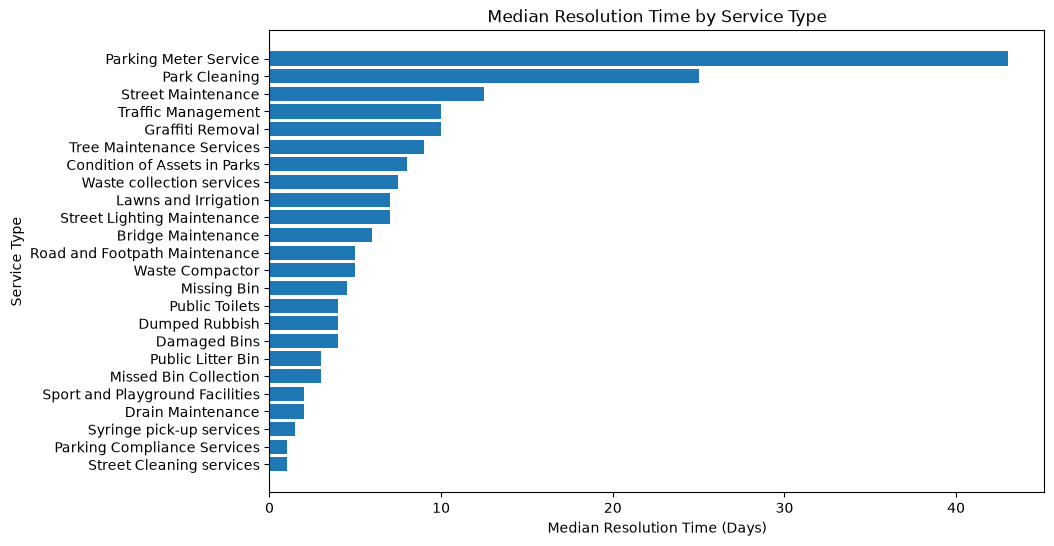

In [20]:
service_median = (
    df.groupby("service_desc")["days_to_complete"]
    .median()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    service_median.index,
    service_median.values
)

plt.xlabel("Median Resolution Time (Days)")
plt.ylabel("Service Type")
plt.title("Median Resolution Time by Service Type")

plt.show()

### Interpretation

Median resolution time differs considerably between service types.

This suggests that `service_desc` contains useful information for predicting resolution time and supports its inclusion as a model feature.

## 7. Feature Engineering

The request date may contain useful information about operational or seasonal differences.

Instead of using the complete date directly, three features are extracted:

- `received_year`
- `received_month`
- `received_day_of_week`

In [21]:
df["received_year"] = df["date_received"].dt.year
df["received_month"] = df["date_received"].dt.month
df["received_day_of_week"] = df["date_received"].dt.dayofweek

df[
    [
        "date_received",
        "received_year",
        "received_month",
        "received_day_of_week"
    ]
].head()

,date_received,received_year,received_month,received_day_of_week
0,2015-11-19,2015,11,3
1,2015-09-14,2015,9,0
2,2015-04-27,2015,4,0
3,2015-03-12,2015,3,3
4,2016-04-07,2016,4,3


In [22]:
df.groupby("received_year")["days_to_complete"].agg(
    ["count", "mean", "median", "max"]
).sort_index()

,count,mean,median,max
received_year,,,,
2014,46,8.478261,3.5,132
2015,320,23.159375,5.5,529
2016,634,10.168770,5.0,171


In [23]:
df.groupby("received_month")["days_to_complete"].agg(
    ["count", "mean", "median", "max"]
).sort_index()

,count,mean,median,max
received_month,,,,
1,52,13.750000,4.0,268
2,59,24.542373,4.0,529
3,66,12.560606,5.0,139
4,58,35.275862,7.0,462
5,63,11.412698,7.0,42
6,108,14.814815,7.0,283
7,168,12.535714,6.0,188
8,157,12.292994,4.0,379
9,83,7.831325,4.0,55


In [24]:
df.groupby("received_day_of_week")["days_to_complete"].agg(
    ["count", "mean", "median", "max"]
).sort_index()

,count,mean,median,max
received_day_of_week,,,,
0,203,16.384236,7.0,353
1,165,10.218182,6.0,107
2,186,11.413978,5.0,379
3,199,18.487437,6.0,462
4,164,15.347561,5.0,529
5,40,5.600000,4.0,22
6,43,16.116279,9.0,232


The date-derived variables were examined before being included in the model.

The year, month and day of week are retained as candidate features because they may capture differences in service demand or operational patterns.

In [25]:
print("Missing suburb values:")
print(df["suburb"].isna().sum())

print("\nMissing percentage:")
print(df["suburb"].isna().mean() * 100)

Missing suburb values:
555

Missing percentage:
55.50000000000001


In [26]:
df.groupby(
    df["suburb"].isna()
)["days_to_complete"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
suburb,,,,
False,445,11.274157,5.0,353
True,555,16.632432,5.0,529


In [27]:
df.groupby("category")["suburb"].apply(
    lambda x: x.isna().mean()
).sort_values(ascending=False)

category
Roads and Traffic                    0.858268
Asset maintenance                    0.833333
Parking                              0.812500
Waste, Street Cleaning and Litter    0.561364
Graffiti                             0.391705
Parks and Trees                      0.340909
Name: suburb, dtype: float64

### Suburb Decision

A substantial proportion of `suburb` values are missing.

The missingness also varies between categories, suggesting that the missing values may not be completely random.

Instead of deleting these observations, missing suburb values will be represented as `Unknown` during preprocessing. This preserves the available data while allowing the model to treat missing location information as a separate category.

## 8. Feature Selection

The following decisions were made based on the data analysis:

| Feature | Decision | Reason |
|---|---|---|
| `category` | Keep | Main service category may affect resolution time |
| `service_desc` | Keep | Provides detailed service information |
| `suburb` | Keep | Location may contain useful signal |
| `received_year` | Keep | Resolution patterns may vary by year |
| `received_month` | Keep | May capture seasonal differences |
| `received_day_of_week` | Keep | May capture operational differences |
| `date_completed` | Exclude | Causes target leakage |
| `request_status` | Exclude | All selected records are `CLOSED` |

### Data Leakage

`date_completed` is not used as a feature because it directly determines `days_to_complete`.

Using this information would allow the model to access information that would only be known after the request had already been completed.

In [28]:
features = [
    "category",
    "service_desc",
    "suburb",
    "received_year",
    "received_month",
    "received_day_of_week"
]

X = df[features]
y = df["days_to_complete"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,category,service_desc,suburb,received_year,received_month,received_day_of_week
0,Roads and Traffic,Traffic Management,NaN,2015,11,3
1,Parking,Parking Compliance Services,Melbourne,2015,9,0
2,Parks and Trees,Tree Maintenance Services,Carlton,2015,4,0
3,Graffiti,Graffiti Removal,East Melbourne,2015,3,3
4,Graffiti,Graffiti Removal,North Melbourne,2016,4,3



Target:


0    26
1     1
2    15
3    11
4     7
Name: days_to_complete, dtype: int64

## 9. Train/Test Split

The dataset is split into training and testing sets using an 80/20 ratio.

A fixed random state is used to make the experiment reproducible.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 6)
X_test: (200, 6)
y_train: (800,)
y_test: (200,)


## 10. Preprocessing

The dataset contains categorical variables such as category, service type and suburb.

These variables are processed using:

- `SimpleImputer` to represent missing categorical values as `Unknown`
- `OneHotEncoder` to convert categorical variables into numerical features
- `ColumnTransformer` to apply the appropriate transformations to each feature type
- `Pipeline` to keep preprocessing and modeling together

Keeping preprocessing inside the pipeline helps make the training and prediction process consistent.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "category",
    "service_desc",
    "suburb"
]

numeric_features = [
    "received_year",
    "received_month",
    "received_day_of_week"
]

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
    (
        "numeric",
        "passthrough",
        numeric_features
    )
])

## 11. Model Training and Evaluation

Because this is a regression problem, accuracy percentage is not an appropriate metric.

The models are evaluated using:

- **MAE (Mean Absolute Error):** average absolute prediction error in days.
- **RMSE (Root Mean Squared Error):** gives more weight to large errors.
- **R²:** measures how much variation in the target is explained by the model.

Lower MAE and RMSE are better. Higher R² is better.

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

baseline_prediction = y_train.mean()

baseline_pred = np.full(
    shape=len(y_test),
    fill_value=baseline_prediction
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 14.495287500000003


The baseline predicts the training-set mean for every test sample.

This provides a simple reference point for evaluating whether the machine learning models provide a meaningful improvement.

In [32]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Linear Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Linear Regression
MAE: 13.271624728811885
RMSE: 27.46517688389479
R²: 0.11786138148145209


### Random Forest Regressor

Random Forest was tested as a non-linear alternative to Linear Regression.

The goal was to determine whether a more flexible model could capture relationships that a linear model might miss.

In [33]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    )
])

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 13.594304945887448
RMSE: 37.000336931175
R²: -0.600970730771617


### Log-Transformed Target

The target variable is strongly right-skewed.

To reduce the influence of extreme resolution times, another Linear Regression experiment was performed using a log-transformed target:

`log1p(y)`

The predictions are then converted back to the original scale using:

`expm1(prediction)`

The features, train/test split and model type remain the same. Only the representation of the target variable is changed.

In [34]:
y_train_log = np.log1p(y_train)

linear_model_log = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model_log.fit(
    X_train,
    y_train_log
)

y_pred_log = linear_model_log.predict(X_test)

y_pred_log_original = np.expm1(
    y_pred_log
)

log_mae = mean_absolute_error(
    y_test,
    y_pred_log_original
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_original
    )
)

log_r2 = r2_score(
    y_test,
    y_pred_log_original
)

print("Log Linear Regression")
print("MAE:", log_mae)
print("RMSE:", log_rmse)
print("R²:", log_r2)

Log Linear Regression
MAE: 9.622680389364241
RMSE: 28.440377342381648
R²: 0.05410540694387633


In [35]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Log Linear Regression"
    ],
    "MAE": [
        baseline_mae,
        mae,
        rf_mae,
        log_mae
    ],
    "RMSE": [
        np.nan,
        rmse,
        rf_rmse,
        log_rmse
    ],
    "R²": [
        np.nan,
        r2,
        rf_r2,
        log_r2
    ]
})

results.round(3)

,Model,MAE,RMSE,R²
0,Baseline,14.495,NaN,NaN
1,Linear Regression,13.272,27.465,0.118
2,Random Forest,13.594,37.000,-0.601
3,Log Linear Regression,9.623,28.440,0.054


### Model Comparison

The log-transformed Linear Regression achieved the lowest MAE among the tested models.

The final MAE is approximately **9.62 days**, meaning that the model's predictions are on average about 9.6 days away from the actual resolution time.

However, the relatively low R² indicates that the current features explain only a limited portion of the variation in resolution time.

Therefore, the model is useful as an approximate estimation tool, but it should not be treated as an exact prediction system.

## 12. Error Analysis

The final model is examined further to understand where its predictions can be inaccurate.

In [36]:
log_error_analysis = X_test.copy()

log_error_analysis["actual"] = y_test.values
log_error_analysis["predicted"] = y_pred_log_original

log_error_analysis["absolute_error"] = (
    log_error_analysis["actual"]
    - log_error_analysis["predicted"]
).abs()

log_error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,category,service_desc,suburb,received_year,received_month,received_day_of_week,actual,predicted,absolute_error
901,Roads and Traffic,Traffic Management,NaN,2015,4,3,251,16.057211,234.942789
321,"Waste, Street Cleaning and Litter",Waste collection services,NaN,2015,11,6,232,6.194247,225.805753
902,Parking,Parking Meter Service,NaN,2015,6,0,183,19.876496,163.123504
294,Roads and Traffic,Traffic Management,NaN,2016,4,4,81,16.116252,64.883748
55,Parks and Trees,Park Cleaning,NaN,2015,7,4,77,23.489754,53.510246
626,"Waste, Street Cleaning and Litter",Dumped Rubbish,Melbourne,2015,9,1,55,3.072064,51.927936
432,Parking,Parking Meter Service,NaN,2016,2,3,67,22.895032,44.104968
826,"Waste, Street Cleaning and Litter",Waste collection services,Melbourne,2014,11,2,48,4.859225,43.140775
636,Graffiti,Graffiti Removal,Melbourne,2016,9,1,49,8.190445,40.809555
713,Parking,Parking Meter Service,NaN,2016,8,3,56,19.894481,36.105519


### Error Analysis Finding

The largest prediction errors occur mainly in requests with unusually long resolution times.

This suggests that the current features do not contain enough information to explain why some individual requests remain open for very long periods.

Additional operational features, historical workload information or more detailed request information could potentially improve these predictions.

## 13. Example Predictions

Three new hypothetical customer service requests are used to demonstrate how the final model can generate individual predictions.

In [37]:
sample_requests = pd.DataFrame({
    "category": [
        "Graffiti",
        "Waste, Street Cleaning and Litter",
        "Roads and Traffic"
    ],
    "service_desc": [
        "Graffiti Removal",
        "Missed Bin Collection",
        "Traffic Management"
    ],
    "suburb": [
        "Melbourne",
        "Carlton",
        "Kensington"
    ],
    "received_year": [
        2016,
        2016,
        2016
    ],
    "received_month": [
        9,
        9,
        9
    ],
    "received_day_of_week": [
        1,
        2,
        3
    ]
})

sample_predictions_log = linear_model_log.predict(
    sample_requests
)

sample_predictions = np.expm1(
    sample_predictions_log
)

prediction_results = sample_requests.copy()

prediction_results["predicted_days"] = (
    sample_predictions.round(2)
)

prediction_results

,category,service_desc,suburb,received_year,received_month,received_day_of_week,predicted_days
0,Graffiti,Graffiti Removal,Melbourne,2016,9,1,8.19
1,"Waste, Street Cleaning and Litter",Missed Bin Collection,Carlton,2016,9,2,2.45
2,Roads and Traffic,Traffic Management,Kensington,2016,9,3,18.35


## 14. Interactive Prediction Tool

The following simple command-line tool allows a user to enter a new request and receive an estimated resolution time.

This satisfies the project requirement for an interactive `input()`-based prediction tool.

In [38]:
def tahmin_et():

    print("Resolve - Customer Service Resolution Time Prediction")
    print("-" * 55)

    category = input("Category: ")
    service_desc = input("Service type: ")
    suburb = input("Suburb: ")

    year = int(input("Year: "))
    month = int(input("Month (1-12): "))
    day_of_week = int(
        input("Day of week (0=Monday, 6=Sunday): ")
    )

    request = pd.DataFrame({
        "category": [category],
        "service_desc": [service_desc],
        "suburb": [suburb],
        "received_year": [year],
        "received_month": [month],
        "received_day_of_week": [day_of_week]
    })

    prediction_log = linear_model_log.predict(
        request
    )

    prediction = np.expm1(
        prediction_log
    )[0]

    print()
    print(
        f"Estimated resolution time: "
        f"approximately {prediction:.1f} days."
    )

In [39]:
tahmin_et()

Resolve - Customer Service Resolution Time Prediction
-------------------------------------------------------

Estimated resolution time: approximately 8.2 days.


## 15. Save Project Artifacts

The cleaned dataset is saved as a CSV file so that the project can be reproduced and shared.

In [40]:
df.to_csv(
    "resolve_dataset.csv",
    index=False
)

print("Dataset saved as resolve_dataset.csv")

Dataset saved as resolve_dataset.csv


In [41]:
import joblib

joblib.dump(
    linear_model_log,
    "resolve_model.pkl"
)

print("Final model saved as resolve_model.pkl")

Final model saved as resolve_model.pkl


## 16. Conclusion

Resolve demonstrates an end-to-end machine learning workflow using real-world customer service data.

The project includes:

- Real-world data collection through an API
- Data cleaning and missing-value handling
- Exploratory data analysis
- Visualization of resolution-time patterns
- Feature engineering from date information
- Data leakage prevention
- Categorical feature encoding
- Baseline, Linear Regression and Random Forest models
- Log-transformed regression
- Model comparison using MAE, RMSE and R²
- Individual predictions
- An interactive `input()` prediction tool
- A saved machine learning model

The best result was achieved by the log-transformed Linear Regression model, with an MAE of approximately **9.62 days**.

However, the relatively low R² shows that the available features explain only a limited part of the variation in resolution time. The model should therefore be considered an estimation tool rather than an exact predictor.

Future improvements could include:

- A larger historical dataset
- More operational features
- Workload or seasonal information
- Additional request-level information
- More advanced regression models such as Gradient Boosting

## Project Outputs

### Files

- `resolve_analysis.ipynb` — Complete analysis and modeling workflow
- `resolve_dataset.csv` — Cleaned dataset
- `resolve_model.pkl` — Trained final model
- `app.py` — Streamlit prediction application

### Technologies

Python · Pandas · NumPy · Matplotlib · Scikit-learn · Joblib · Streamlit